In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Load the dataset
df = pd.read_csv(r"C:\Users\hp\Music\DEPI Data Analysis\DEPI HR  Project\HRData_Final.csv")

# Display the first few rows
df.head()

,EmployeeID,FirstName,LastName,Gender,Age,BusinessTravel,Department,DistanceFromHome (KM),State,Ethnicity,...,ManagerRating,Scaled_Total_Employee_Rating,Scaled_Total_Employee_Satisfaction,EducationLevelID,EducationLevel,RatingID,RatingLevel,SatisfactionID,SatisfactionLevel,age_group
0,3012-1A41,Leonelle,Simco,Female,30,Some Travel,Sales,27,IL,White,...,3.0,2.0,3.0,5,Doctorate Degree,3.0,Meets Expectation,3.0,Neutral,Age in(25-35)
1,3012-1A41,Leonelle,Simco,Female,30,Some Travel,Sales,27,IL,White,...,2.0,1.0,3.0,5,Doctorate Degree,2.0,Needs Improvement,4.0,Satisfied,Age in(25-35)
2,3012-1A41,Leonelle,Simco,Female,30,Some Travel,Sales,27,IL,White,...,5.0,5.0,5.0,5,Doctorate Degree,5.0,Above and Beyond,5.0,Very Satisfied,Age in(25-35)
3,3012-1A41,Leonelle,Simco,Female,30,Some Travel,Sales,27,IL,White,...,4.0,4.0,2.0,5,Doctorate Degree,4.0,Exceeds Expectation,3.0,Neutral,Age in(25-35)
4,3012-1A41,Leonelle,Simco,Female,30,Some Travel,Sales,27,IL,White,...,3.0,3.0,3.0,5,Doctorate Degree,3.0,Meets Expectation,4.0,Satisfied,Age in(25-35)


In [2]:
#Q1: Count of Employees

# Python code
employee_count = df['EmployeeID'].nunique()
print(f"Total Employees: {employee_count}")

# Visualization - Simple metric display (no chart needed)

Total Employees: 1470


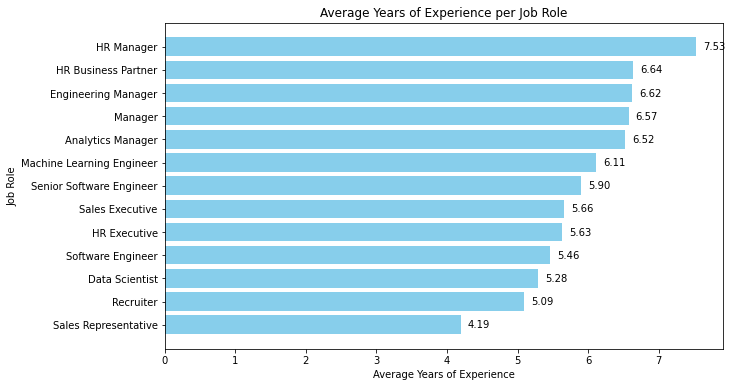

In [3]:
# Q2: AVG Years Of Experience at company per Job Role
avg_experience_per_jobrole = df.groupby('JobRole')['YearsAtCompany'].mean().reset_index()
avg_experience_per_jobrole = avg_experience_per_jobrole.sort_values(by='YearsAtCompany', ascending=False)

# Plot the data
plt.figure(figsize=(10, 6))
bars = plt.barh(avg_experience_per_jobrole['JobRole'], avg_experience_per_jobrole['YearsAtCompany'], color='skyblue')
plt.xlabel('Average Years of Experience')
plt.ylabel('Job Role')
plt.title('Average Years of Experience per Job Role')
plt.gca().invert_yaxis()  # To display the highest on top

# Add data labels to the bars
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.1, bar.get_y() + bar.get_height() / 2,
             f'{width:.2f}', va='center', ha='left', color='black')

plt.show()



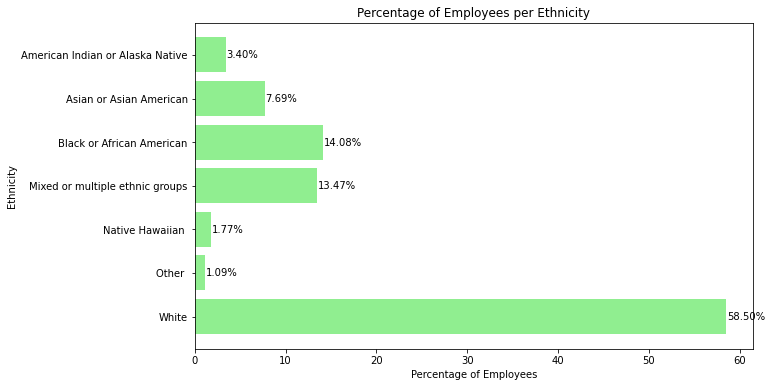

,Ethnicity,EmployeeID,PercentageEmployee
0,American Indian or Alaska Native,50,3.401361
1,Asian or Asian American,113,7.687075
2,Black or African American,207,14.081633
3,Mixed or multiple ethnic groups,198,13.469388
4,Native Hawaiian,26,1.768707
5,Other,16,1.088435
6,White,860,58.503401


In [4]:
# Q3: Count of Employees Per Ethnicity
ethnicity_count = df.groupby('Ethnicity')['EmployeeID'].nunique().reset_index()
ethnicity_count['PercentageEmployee'] = 100.0 * ethnicity_count['EmployeeID'] / ethnicity_count['EmployeeID'].sum()

# Plot the data
plt.figure(figsize=(10, 6))
bars = plt.barh(ethnicity_count['Ethnicity'], ethnicity_count['PercentageEmployee'], color='lightgreen')
plt.xlabel('Percentage of Employees')
plt.ylabel('Ethnicity')
plt.title('Percentage of Employees per Ethnicity')
plt.gca().invert_yaxis()  # To display the highest on top

# Add data labels to the bars
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.1, bar.get_y() + bar.get_height() / 2,
             f'{width:.2f}%', va='center', ha='left', color='black')

plt.show()

ethnicity_count


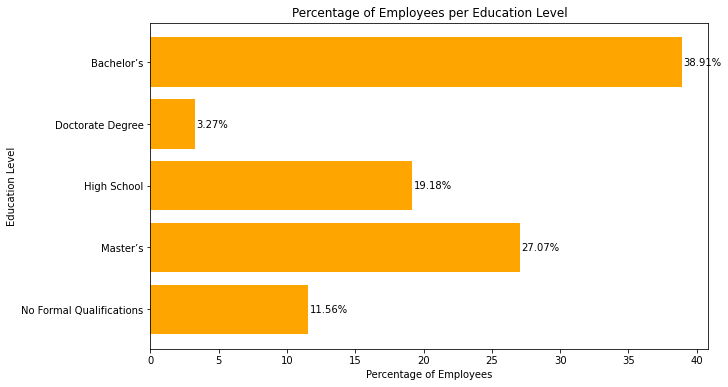

,EducationLevel,EmployeeID,PercentageEmployee
0,Bachelor’s,572,38.911565
1,Doctorate Degree,48,3.265306
2,High School,282,19.183673
3,Master’s,398,27.074830
4,No Formal Qualifications,170,11.564626


In [5]:
# Q4: % of Employees per Education Level
education_level_count = df.groupby('EducationLevel')['EmployeeID'].nunique().reset_index()
education_level_count['PercentageEmployee'] = 100.0 * education_level_count['EmployeeID'] / education_level_count['EmployeeID'].sum()

# Plot the data
plt.figure(figsize=(10, 6))
bars = plt.barh(education_level_count['EducationLevel'], education_level_count['PercentageEmployee'], color='orange')
plt.xlabel('Percentage of Employees')
plt.ylabel('Education Level')
plt.title('Percentage of Employees per Education Level')
plt.gca().invert_yaxis()  # To display the highest on top

# Add data labels to the bars
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.1, bar.get_y() + bar.get_height() / 2,
             f'{width:.2f}%', va='center', ha='left', color='black')

plt.show()

education_level_count


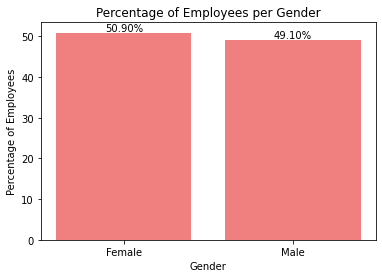

,Gender,EmployeeID,PercentageEmployee
0,Female,675,50.904977
1,Male,651,49.095023


In [6]:
# Q5: % of Employees per Gender
gender_count = df[df['Gender'].isin(['Female', 'Male'])].groupby('Gender')['EmployeeID'].nunique().reset_index()
gender_count['PercentageEmployee'] = 100.0 * gender_count['EmployeeID'] / gender_count['EmployeeID'].sum()

# Plot the data
plt.figure(figsize=(6, 4))
bars = plt.bar(gender_count['Gender'], gender_count['PercentageEmployee'], color='lightcoral')
plt.xlabel('Gender')
plt.ylabel('Percentage of Employees')
plt.title('Percentage of Employees per Gender')

# Add data labels to the bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.5, f'{height:.2f}%', ha='center', color='black')

plt.show()

gender_count


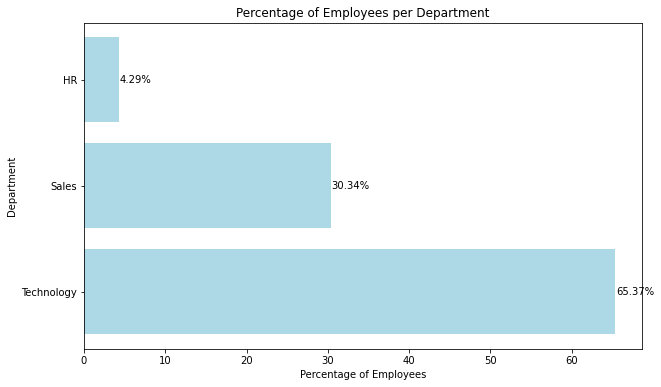

,Department,EmployeeID,PercentageEmployee
0,HR,63,4.285714
1,Sales,446,30.340136
2,Technology,961,65.374150


In [7]:
# Q6: Percentage and Count of Employees per Department
department_count = df.groupby('Department')['EmployeeID'].nunique().reset_index()
department_count['PercentageEmployee'] = 100.0 * department_count['EmployeeID'] / department_count['EmployeeID'].sum()

# Plot the data
plt.figure(figsize=(10, 6))
bars = plt.barh(department_count['Department'], department_count['PercentageEmployee'], color='lightblue')
plt.xlabel('Percentage of Employees')
plt.ylabel('Department')
plt.title('Percentage of Employees per Department')
plt.gca().invert_yaxis()  # To display the highest on top

# Add data labels to the bars
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.1, bar.get_y() + bar.get_height() / 2,
             f'{width:.2f}%', va='center', ha='left', color='black')

plt.show()

department_count


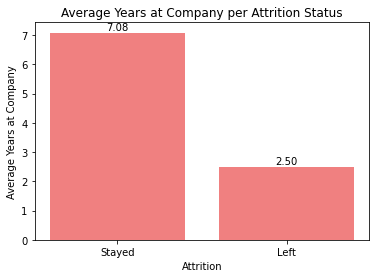

,Attrition,YearsAtCompany
0,No,7.07956
1,Yes,2.49801


In [8]:
# Q7: Attrition Rate Per Average YearsAtCompany for Active Employees
attrition_avg_years = df.groupby('Attrition')['YearsAtCompany'].mean().reset_index()

# Plot the data
plt.figure(figsize=(6, 4))
bars = plt.bar(attrition_avg_years['Attrition'], attrition_avg_years['YearsAtCompany'], color='lightcoral')
plt.xlabel('Attrition')
plt.ylabel('Average Years at Company')
plt.title('Average Years at Company per Attrition Status')
plt.xticks([0, 1], ['Stayed', 'Left'])

# Add data labels to the bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.1, f'{height:.2f}', ha='center', color='black')

plt.show()

attrition_avg_years


Attrition Rate: 16.12%
Number of employees who left: 237 out of 1470 employees.


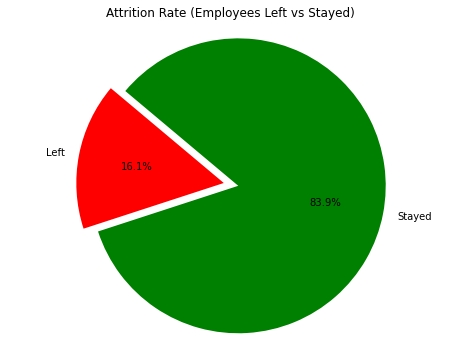

In [9]:
# Q8: Attrition Rate

# تحديد الأعمدة المطلوبة
unique_employees = df[['EmployeeID', 'Attrition']].drop_duplicates()

# حساب نسبة الاستقالة لكل حالة (نسبة الموظفين الذين استقالوا)
attrition_rate = unique_employees['Attrition'].value_counts(normalize=True) * 100

# حساب عدد الموظفين الذين تركوا الشركة
attrition_count = unique_employees['Attrition'].value_counts()

# تحديد العدد الإجمالي للموظفين
total_employees = len(unique_employees)

# طباعة النتيجة
print(f"Attrition Rate: {attrition_rate[1]:.2f}%")
print(f"Number of employees who left: {attrition_count[1]} out of {total_employees} employees.")

# رسم البيانات كـ Pie chart
labels = ['Left', 'Stayed']
sizes = [attrition_count[1], total_employees - attrition_count[1]]
colors = ['red', 'green']
explode = (0.1, 0)  # زيادة الفقاعة لمجموعة 'Left' فقط لتمييزها

plt.figure(figsize=(8, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors, explode=explode)
plt.title('Attrition Rate (Employees Left vs Stayed)')
plt.axis('equal')  # لضمان أن يكون الرسم دائريًا

# عرض الرسم البياني
plt.show()


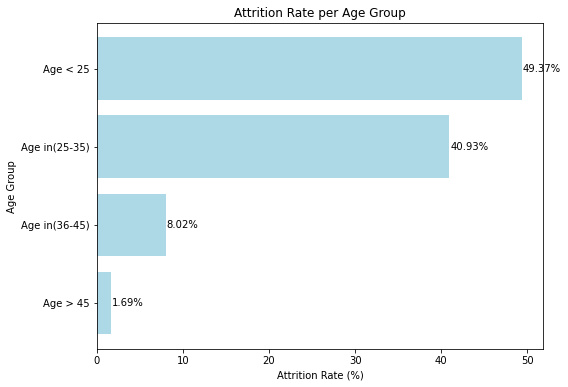

       age_group  Attrition  EmployeeID  AttritionRate
0       Age < 25        117         650      49.367089
1  Age in(25-35)         97         497      40.928270
2  Age in(36-45)         19         252       8.016878
3       Age > 45          4          71       1.687764


In [10]:
# Q9: Attrition Rate Per Age Group

# تحديد الأعمدة المطلوبة
unique_employees = df[['EmployeeID', 'Attrition', 'Age']].drop_duplicates()

# تحويل القيم النصية في Attrition إلى أرقام (0 = لم يتركوا الشركة, 1 = تركوا الشركة)
unique_employees['Attrition'] = unique_employees['Attrition'].map({'No': 0, 'Yes': 1})

# إنشاء فئات عمرية
bins = [0, 25, 35, 45, float('inf')]
labels = ['Age < 25', 'Age in(25-35)', 'Age in(36-45)', 'Age > 45']
unique_employees['age_group'] = pd.cut(unique_employees['Age'], bins=bins, labels=labels)

# حساب عدد الموظفين الذين تركوا الشركة في كل فئة عمرية
age_group_attrition = unique_employees.groupby('age_group').agg({
    'Attrition': 'sum',  # عدد الموظفين الذين تركوا الشركة
    'EmployeeID': 'count'  # إجمالي عدد الموظفين في كل فئة
}).reset_index()

# تحديد العدد الإجمالي للموظفين الذين تركوا الشركة (237)
total_attrition = 237  # إجمالي عدد الموظفين الذين تركوا الشركة

# حساب معدل الاستقالة بناءً على العدد الإجمالي للموظفين الذين تركوا الشركة (237)
age_group_attrition['AttritionRate'] = (age_group_attrition['Attrition'] / total_attrition) * 100

# رسم البيانات
plt.figure(figsize=(8, 6))
bars = plt.barh(age_group_attrition['age_group'], age_group_attrition['AttritionRate'], color='lightblue')
plt.xlabel('Attrition Rate (%)')
plt.ylabel('Age Group')
plt.title('Attrition Rate per Age Group')
plt.gca().invert_yaxis()  # To display the highest on top

# إضافة البيانات على الرسم البياني
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.1, bar.get_y() + bar.get_height() / 2,
             f'{width:.2f}%', va='center', ha='left', color='black')

plt.show()

# عرض الجدول مع النسب المئوية
print(age_group_attrition)


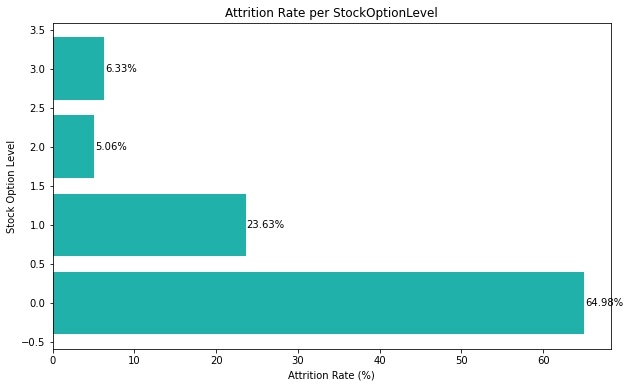

   StockOptionLevel  Attrition  EmployeeID  AttritionRate
0                 0        154         631      64.978903
1                 1         56         596      23.628692
2                 2         12         158       5.063291
3                 3         15          85       6.329114


,StockOptionLevel,Attrition,EmployeeID,AttritionRate
0,0,154,631,64.978903
1,1,56,596,23.628692
2,2,12,158,5.063291
3,3,15,85,6.329114


In [11]:
# Q11: Attrition Rate Per StockOptionLevel

# تحديد الأعمدة المطلوبة
unique_employees = df[['EmployeeID', 'Attrition', 'StockOptionLevel']].drop_duplicates()

# تحويل قيم `Attrition` إلى أرقام (0 = لم يتركوا الشركة, 1 = تركوا الشركة)
unique_employees['Attrition'] = unique_employees['Attrition'].map({'No': 0, 'Yes': 1})

# حساب عدد الموظفين الذين تركوا الشركة حسب مستوى خيار الأسهم
stock_option_attrition = unique_employees.groupby('StockOptionLevel').agg({
    'Attrition': 'sum',  # عدد الموظفين الذين تركوا الشركة
    'EmployeeID': 'count'  # إجمالي عدد الموظفين في كل مستوى
}).reset_index()

# تحديد العدد الإجمالي للموظفين الذين تركوا الشركة (237)
total_attrition = 237  # إجمالي عدد الموظفين الذين تركوا الشركة

# حساب معدل الاستقالة بناءً على العدد الإجمالي للموظفين الذين تركوا الشركة (237)
stock_option_attrition['AttritionRate'] = (stock_option_attrition['Attrition'] / total_attrition) * 100

# رسم البيانات
plt.figure(figsize=(10, 6))
bars = plt.barh(stock_option_attrition['StockOptionLevel'], stock_option_attrition['AttritionRate'], color='lightseagreen')
plt.xlabel('Attrition Rate (%)')
plt.ylabel('Stock Option Level')
plt.title('Attrition Rate per StockOptionLevel')

# إضافة البيانات على الرسم البياني
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.1, bar.get_y() + bar.get_height() / 2,
             f'{width:.2f}%', va='center', ha='left', color='black')

plt.show()

# عرض الجدول مع النسب المئوية
print(stock_option_attrition)


stock_option_attrition


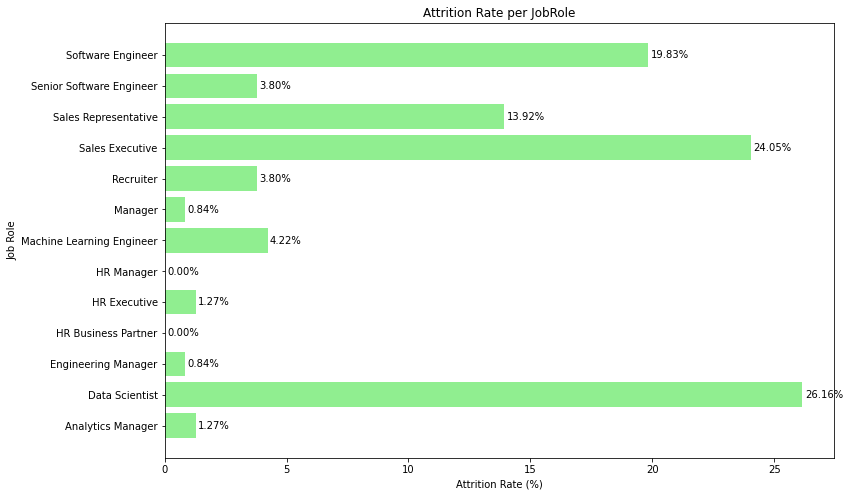

                      JobRole  Attrition  EmployeeID  AttritionRate
0           Analytics Manager          3          52       1.265823
1              Data Scientist         62         261      26.160338
2         Engineering Manager          2          75       0.843882
3         HR Business Partner          0           7       0.000000
4                HR Executive          3          28       1.265823
5                  HR Manager          0           4       0.000000
6   Machine Learning Engineer         10         146       4.219409
7                     Manager          2          37       0.843882
8                   Recruiter          9          24       3.797468
9             Sales Executive         57         327      24.050633
10       Sales Representative         33          83      13.924051
11   Senior Software Engineer          9         132       3.797468
12          Software Engineer         47         294      19.831224


In [12]:
# Q12: Attrition Rate Per JobRole

# تحديد الأعمدة المطلوبة
unique_employees = df[['EmployeeID', 'Attrition', 'JobRole']].drop_duplicates()

# تحويل قيم `Attrition` إلى أرقام (0 = لم يتركوا الشركة, 1 = تركوا الشركة)
unique_employees['Attrition'] = unique_employees['Attrition'].map({'No': 0, 'Yes': 1})

# حساب عدد الموظفين الذين تركوا الشركة حسب الوظيفة
job_role_attrition = unique_employees.groupby('JobRole').agg({
    'Attrition': 'sum',  # عدد الموظفين الذين تركوا الشركة
    'EmployeeID': 'count'  # إجمالي عدد الموظفين في كل وظيفة
}).reset_index()

# تحديد العدد الإجمالي للموظفين الذين تركوا الشركة (237)
total_attrition = 237  # إجمالي عدد الموظفين الذين تركوا الشركة

# حساب معدل الاستقالة بناءً على العدد الإجمالي للموظفين الذين تركوا الشركة (237)
job_role_attrition['AttritionRate'] = (job_role_attrition['Attrition'] / total_attrition) * 100

# رسم البيانات
plt.figure(figsize=(12, 8))
bars = plt.barh(job_role_attrition['JobRole'], job_role_attrition['AttritionRate'], color='lightgreen')
plt.xlabel('Attrition Rate (%)')
plt.ylabel('Job Role')
plt.title('Attrition Rate per JobRole')

# إضافة البيانات على الرسم البياني
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.1, bar.get_y() + bar.get_height() / 2,
             f'{width:.2f}%', va='center', ha='left', color='black')

plt.show()

# عرض الجدول مع النسب المئوية
print(job_role_attrition)



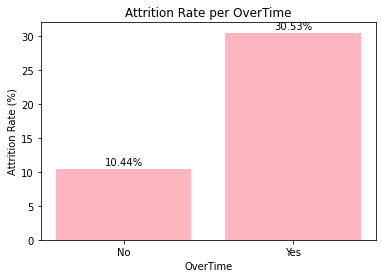

,OverTime,EmployeeID,Attrition,AttritionRate
0,No,1054,110,10.436433
1,Yes,416,127,30.528846


In [13]:
# Q13: Attrition Rate Per OverTime
unique_employees = df[['EmployeeID', 'Attrition', 'OverTime']].drop_duplicates()

# تحويل قيم `Attrition` إلى أرقام (0 = لم يتركوا الشركة, 1 = تركوا الشركة)
unique_employees['Attrition'] = unique_employees['Attrition'].map({'No': 0, 'Yes': 1})

# حساب معدل الاستقالة حسب العمل الإضافي
overtime_attrition = unique_employees.groupby('OverTime').agg({
    'EmployeeID': 'count',
    'Attrition': 'sum'
}).reset_index()

# حساب نسبة الاستقالة
overtime_attrition['AttritionRate'] = 100.0 * overtime_attrition['Attrition'] / overtime_attrition['EmployeeID']

# رسم البيانات
plt.figure(figsize=(6, 4))
bars = plt.bar(overtime_attrition['OverTime'], overtime_attrition['AttritionRate'], color='lightpink')
plt.xlabel('OverTime')
plt.ylabel('Attrition Rate (%)')
plt.title('Attrition Rate per OverTime')

# إضافة البيانات على الرسم البياني
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.5, f'{height:.2f}%', ha='center', color='black')

plt.show()

overtime_attrition


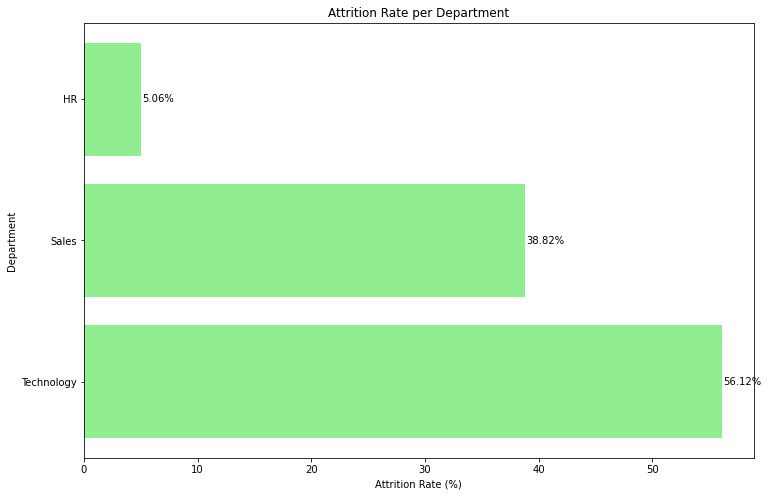

   Department  Attrition  EmployeeID  AttritionRate
0          HR         12          63       5.063291
1       Sales         92         446      38.818565
2  Technology        133         961      56.118143


In [14]:

# Q14: Attrition Rate Per Department

# تحديد الأعمدة المطلوبة
unique_employees = df[['EmployeeID', 'Attrition', 'Department']].drop_duplicates()

# تحويل قيم `Attrition` إلى أرقام (0 = لم يتركوا الشركة, 1 = تركوا الشركة)
unique_employees['Attrition'] = unique_employees['Attrition'].map({'No': 0, 'Yes': 1})

# حساب عدد الموظفين الذين تركوا الشركة حسب القسم
department_attrition = unique_employees.groupby('Department').agg({
    'Attrition': 'sum',  # عدد الموظفين الذين تركوا الشركة
    'EmployeeID': 'count'  # إجمالي عدد الموظفين في كل قسم
}).reset_index()

# تحديد العدد الإجمالي للموظفين الذين تركوا الشركة (237)
total_attrition = 237  # إجمالي عدد الموظفين الذين تركوا الشركة

# حساب معدل الاستقالة بناءً على العدد الإجمالي للموظفين الذين تركوا الشركة (237)
department_attrition['AttritionRate'] = (department_attrition['Attrition'] / total_attrition) * 100

# رسم البيانات
plt.figure(figsize=(12, 8))
bars = plt.barh(department_attrition['Department'], department_attrition['AttritionRate'], color='lightgreen')
plt.xlabel('Attrition Rate (%)')
plt.ylabel('Department')
plt.title('Attrition Rate per Department')
plt.gca().invert_yaxis()  # To display the highest on top

# إضافة البيانات على الرسم البياني
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.1, bar.get_y() + bar.get_height() / 2,
             f'{width:.2f}%', va='center', ha='left', color='black')

plt.show()

# عرض الجدول مع النسب المئوية
print(department_attrition)



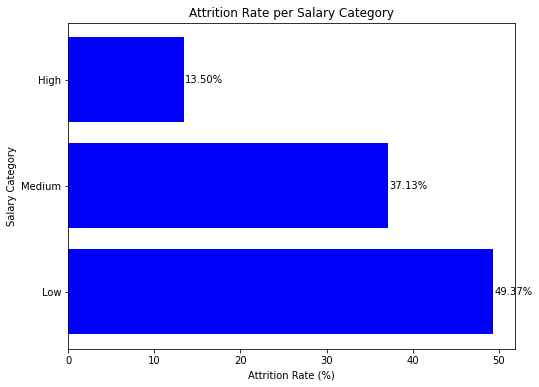

  SalaryCategory  EmployeeID  Attrition  AttritionRate
0            Low         473        117      49.367089
1         Medium         651         88      37.130802
2           High         346         32      13.502110


In [15]:
# Q15: Attrition Rate Per Salary Category

# تحديد الأعمدة المطلوبة
unique_employees = df[['EmployeeID', 'Attrition', 'Salary']].drop_duplicates()

# تحويل قيم `Attrition` إلى أرقام (0 = لم يتركوا الشركة, 1 = تركوا الشركة)
unique_employees['Attrition'] = unique_employees['Attrition'].map({'No': 0, 'Yes': 1})

# تصنيف الراتب إلى ثلاث فئات: Low, Medium, High
unique_employees['SalaryCategory'] = pd.cut(unique_employees['Salary'], bins=[0, 50000, 150000, float('inf')],
                                            labels=['Low', 'Medium', 'High'])

# حساب معدل الاستقالة حسب فئة الراتب
salary_attrition = unique_employees.groupby('SalaryCategory').agg({
    'EmployeeID': 'count',
    'Attrition': 'sum'
}).reset_index()

# تحديد العدد الإجمالي للموظفين الذين تركوا الشركة (237)
total_attrition = 237  # إجمالي عدد الموظفين الذين تركوا الشركة

# حساب معدل الاستقالة بناءً على العدد الإجمالي للموظفين الذين استقالوا (237)
salary_attrition['AttritionRate'] = (salary_attrition['Attrition'] / total_attrition) * 100

# رسم البيانات
plt.figure(figsize=(8, 6))
bars = plt.barh(salary_attrition['SalaryCategory'], salary_attrition['AttritionRate'], color='blue')
plt.xlabel('Attrition Rate (%)')
plt.ylabel('Salary Category')
plt.title('Attrition Rate per Salary Category')

# إضافة البيانات على الرسم البياني
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.1, bar.get_y() + bar.get_height() / 2,
             f'{width:.2f}%', va='center', ha='left', color='black')

plt.show()

# عرض الجدول مع النسب المئوية
print(salary_attrition)


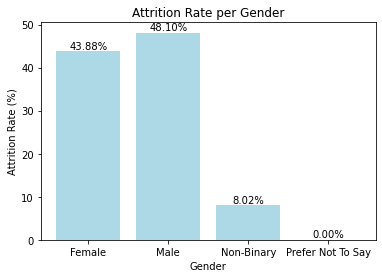

              Gender  Attrition  EmployeeID  AttritionRate
0             Female        104         675      43.881857
1               Male        114         651      48.101266
2         Non-Binary         19         124       8.016878
3  Prefer Not To Say          0          20       0.000000


In [16]:
# Q16: Attrition Rate Per Gender

# تحديد الأعمدة المطلوبة
unique_employees = df[['EmployeeID', 'Attrition', 'Gender']].drop_duplicates()

# تحويل قيم `Attrition` إلى أرقام (0 = لم يتركوا الشركة, 1 = تركوا الشركة)
unique_employees['Attrition'] = unique_employees['Attrition'].map({'No': 0, 'Yes': 1})

# حساب عدد الموظفين الذين تركوا الشركة حسب الجنس
gender_attrition = unique_employees.groupby('Gender').agg({
    'Attrition': 'sum',  # عدد الموظفين الذين تركوا الشركة
    'EmployeeID': 'count'  # إجمالي عدد الموظفين في كل فئة من فئات الجنس
}).reset_index()

# تحديد العدد الإجمالي للموظفين الذين تركوا الشركة (237)
total_attrition = 237  # إجمالي عدد الموظفين الذين تركوا الشركة

# حساب معدل الاستقالة بناءً على العدد الإجمالي للموظفين الذين تركوا الشركة (237)
gender_attrition['AttritionRate'] = (gender_attrition['Attrition'] / total_attrition) * 100

# رسم البيانات
plt.figure(figsize=(6, 4))
bars = plt.bar(gender_attrition['Gender'], gender_attrition['AttritionRate'], color='lightblue')
plt.xlabel('Gender')
plt.ylabel('Attrition Rate (%)')
plt.title('Attrition Rate per Gender')

# إضافة البيانات على الرسم البياني
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.5, f'{height:.2f}%', ha='center', color='black')

plt.show()

# عرض الجدول مع النسب المئوية
print(gender_attrition)


In [17]:
# Q17: Average Performance Score
avg_performance_score = df['Scaled_Total_Employee_Rating'].mean()

# Print the result
print(f"Avg Performance Score: {avg_performance_score:.2f}")


Avg Performance Score: 2.97


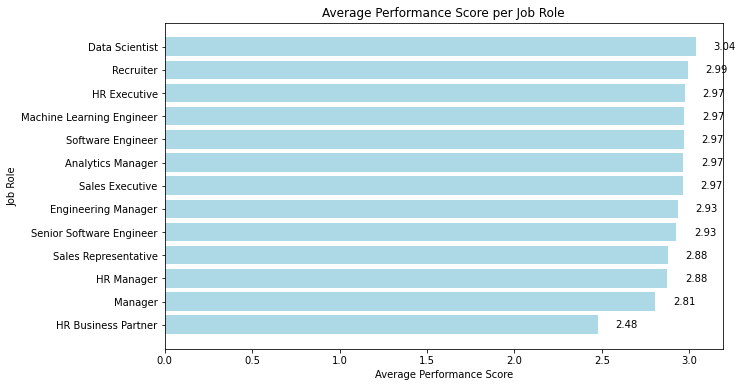

,JobRole,Scaled_Total_Employee_Rating
1,Data Scientist,3.039706
8,Recruiter,2.993289
4,HR Executive,2.973913
6,Machine Learning Engineer,2.973118
12,Software Engineer,2.967766
0,Analytics Manager,2.966346
9,Sales Executive,2.965155
2,Engineering Manager,2.933775
11,Senior Software Engineer,2.927126
10,Sales Representative,2.879346


In [18]:
# Q18: Avg PerformanceScore Per JobRole
avg_performance_per_jobrole = df.groupby('JobRole')['Scaled_Total_Employee_Rating'].mean().reset_index()
avg_performance_per_jobrole = avg_performance_per_jobrole.sort_values(by='Scaled_Total_Employee_Rating', ascending=False)

# Plot the data
plt.figure(figsize=(10, 6))
bars = plt.barh(avg_performance_per_jobrole['JobRole'], avg_performance_per_jobrole['Scaled_Total_Employee_Rating'], color='lightblue')
plt.xlabel('Average Performance Score')
plt.ylabel('Job Role')
plt.title('Average Performance Score per Job Role')
plt.gca().invert_yaxis()  # To display the highest on top

# Add data labels to the bars
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.1, bar.get_y() + bar.get_height() / 2,
             f'{width:.2f}', va='center', ha='left', color='black')

plt.show()

avg_performance_per_jobrole


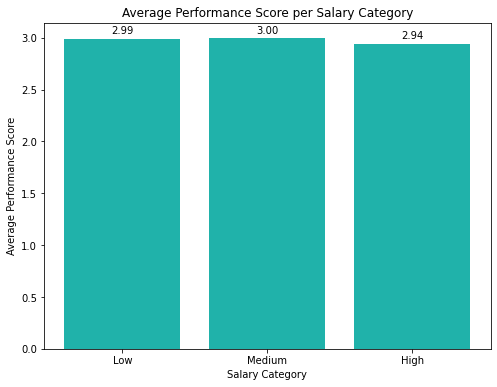

,SalaryCategory,Scaled_Total_Employee_Rating
0,Low,2.986990
1,Medium,2.996115
2,High,2.943483


In [19]:
# Q19: Avg PerformanceScore Per Salary
unique_employees = df[['EmployeeID', 'Scaled_Total_Employee_Rating', 'Salary']].drop_duplicates()

# تصنيف الراتب إلى ثلاث فئات: Low, Medium, High
unique_employees['SalaryCategory'] = pd.cut(unique_employees['Salary'], bins=[0, 50000, 150000, float('inf')],
                                            labels=['Low', 'Medium', 'High'])

# حساب متوسط درجة الأداء حسب فئة الراتب
salary_performance = unique_employees.groupby('SalaryCategory')['Scaled_Total_Employee_Rating'].mean().reset_index()

# Plot the data
plt.figure(figsize=(8, 6))
bars = plt.bar(salary_performance['SalaryCategory'], salary_performance['Scaled_Total_Employee_Rating'], color='lightseagreen')
plt.xlabel('Salary Category')
plt.ylabel('Average Performance Score')
plt.title('Average Performance Score per Salary Category')

# Add data labels to the bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.05, f'{height:.2f}', ha='center', color='black')

plt.show()

salary_performance


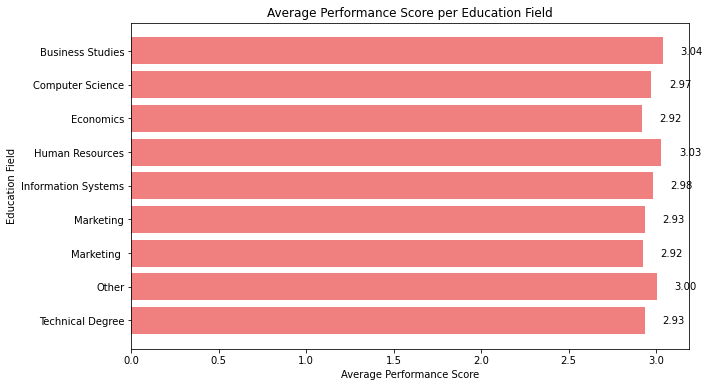

,EducationField,Scaled_Total_Employee_Rating
0,Business Studies,3.037363
1,Computer Science,2.971902
2,Economics,2.919283
3,Human Resources,3.030075
4,Information Systems,2.981205
5,Marketing,2.934447
6,Marketing,2.922775
7,Other,3.002710
8,Technical Degree,2.934211


In [20]:
# Q20: Avg PerformanceScore Per EducationField
education_field_performance = df.groupby('EducationField')['Scaled_Total_Employee_Rating'].mean().reset_index()

# Plot the data
plt.figure(figsize=(10, 6))
bars = plt.barh(education_field_performance['EducationField'], education_field_performance['Scaled_Total_Employee_Rating'], color='lightcoral')
plt.xlabel('Average Performance Score')
plt.ylabel('Education Field')
plt.title('Average Performance Score per Education Field')
plt.gca().invert_yaxis()  # To display the highest on top

# Add data labels to the bars
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.1, bar.get_y() + bar.get_height() / 2,
             f'{width:.2f}', va='center', ha='left', color='black')

plt.show()

education_field_performance


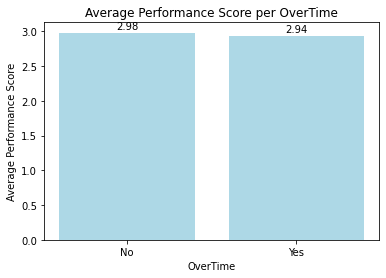

,OverTime,Scaled_Total_Employee_Rating
0,No,2.980322
1,Yes,2.939204


In [21]:
# Q21: Avg PerformanceScore Per OverTime
overtime_performance = df.groupby('OverTime')['Scaled_Total_Employee_Rating'].mean().reset_index()

# Plot the data
plt.figure(figsize=(6, 4))
bars = plt.bar(overtime_performance['OverTime'], overtime_performance['Scaled_Total_Employee_Rating'], color='lightblue')
plt.xlabel('OverTime')
plt.ylabel('Average Performance Score')
plt.title('Average Performance Score per OverTime')

# Add data labels to the bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.05, f'{height:.2f}', ha='center', color='black')

plt.show()

overtime_performance


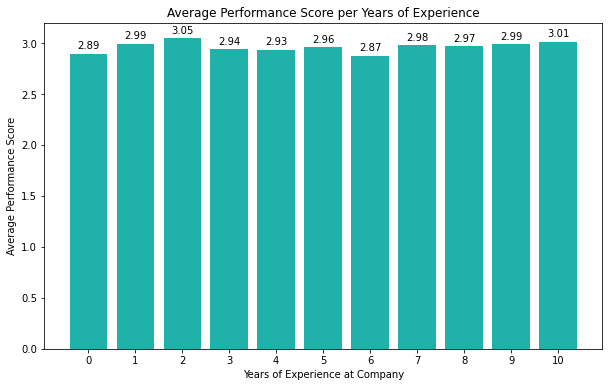

    YearsAtCompany  Scaled_Total_Employee_Rating
0                0                      2.894737
1                1                      2.993641
2                2                      3.047059
3                3                      2.938462
4                4                      2.931770
5                5                      2.957935
6                6                      2.872340
7                7                      2.978462
8                8                      2.966443
9                9                      2.988124
10              10                      3.012560


In [22]:
# Q22: Avg PerformanceScore per Years of Experience
years_experience_performance = df.groupby('YearsAtCompany')['Scaled_Total_Employee_Rating'].mean().reset_index()

# Plot the data
plt.figure(figsize=(10, 6))
bars = plt.bar(years_experience_performance['YearsAtCompany'], years_experience_performance['Scaled_Total_Employee_Rating'], color='lightseagreen')
plt.xlabel('Years of Experience at Company')
plt.ylabel('Average Performance Score')
plt.title('Average Performance Score per Years of Experience')

# تعديل قيم المحور X (من 0 إلى 10 فقط)
plt.xticks(range(11))  # القيم من 0 إلى 10

# إضافة البيانات على الأشرطة
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.05, f'{height:.2f}', ha='center', color='black')

plt.show()

# عرض النتيجة
print(years_experience_performance)


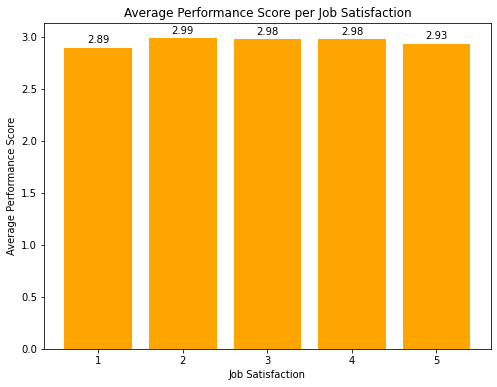

,JobSatisfaction,Scaled_Total_Employee_Rating
0,1.0,2.892308
1,2.0,2.987455
2,3.0,2.975167
3,4.0,2.976261
4,5.0,2.931166


In [23]:
# Q23: Avg PerformanceScore per Job Satisfaction
job_satisfaction_performance = df.groupby('JobSatisfaction')['Scaled_Total_Employee_Rating'].mean().reset_index()

# Plot the data
plt.figure(figsize=(8, 6))
bars = plt.bar(job_satisfaction_performance['JobSatisfaction'], job_satisfaction_performance['Scaled_Total_Employee_Rating'], color='orange')
plt.xlabel('Job Satisfaction')
plt.ylabel('Average Performance Score')
plt.title('Average Performance Score per Job Satisfaction')

# Add data labels to the bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.05, f'{height:.2f}', ha='center', color='black')

plt.show()

job_satisfaction_performance


In [24]:
# Q24: Avg Job Satisfaction
avg_job_satisfaction = df['JobSatisfaction'].mean()

# عدد الموظفين
total_employees = df['EmployeeID'].nunique()

# طباعة النتيجة
print(f"Avg Job Satisfaction: {avg_job_satisfaction:.2f}")
print(f"Total Employees: {total_employees}")


Avg Job Satisfaction: 3.43
Total Employees: 1470


C:\Users\hp\AppData\Local\Temp\ipykernel_23128\1984870806.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  unique_employees['age_group'] = pd.cut(unique_employees['Age'], bins=bins, labels=labels)


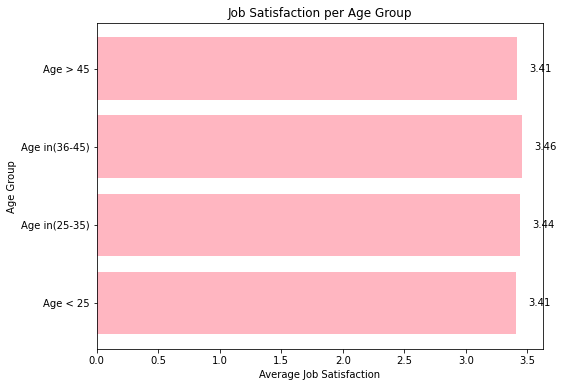

       age_group  JobSatisfaction
0       Age < 25         3.409587
1  Age in(25-35)         3.435869
2  Age in(36-45)         3.455645
3       Age > 45         3.412214


In [25]:
# Q25: Job Satisfaction Per Age Group

# استخدام جميع بيانات الموظفين دون حذف التكرار
# حساب الرضا الوظيفي حسب الفئة العمرية
unique_employees = df[['EmployeeID', 'JobSatisfaction', 'Age']]

# تقسيم الموظفين حسب الفئة العمرية
bins = [0, 25, 35, 45, float('inf')]
labels = ['Age < 25', 'Age in(25-35)', 'Age in(36-45)', 'Age > 45']
unique_employees['age_group'] = pd.cut(unique_employees['Age'], bins=bins, labels=labels)

# حساب متوسط الرضا الوظيفي حسب الفئة العمرية
age_group_job_satisfaction = unique_employees.groupby('age_group').agg({'JobSatisfaction': 'mean'}).reset_index()

# رسم البيانات
plt.figure(figsize=(8, 6))
bars = plt.barh(age_group_job_satisfaction['age_group'], age_group_job_satisfaction['JobSatisfaction'], color='lightpink')
plt.xlabel('Average Job Satisfaction')
plt.ylabel('Age Group')
plt.title('Job Satisfaction per Age Group')

# إضافة البيانات على الرسم البياني
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.1, bar.get_y() + bar.get_height() / 2,
             f'{width:.2f}', va='center', ha='left', color='black')

plt.show()

# طباعة الجدول الخاص بالرائع الوظيفي حسب الفئة العمرية
print(age_group_job_satisfaction)



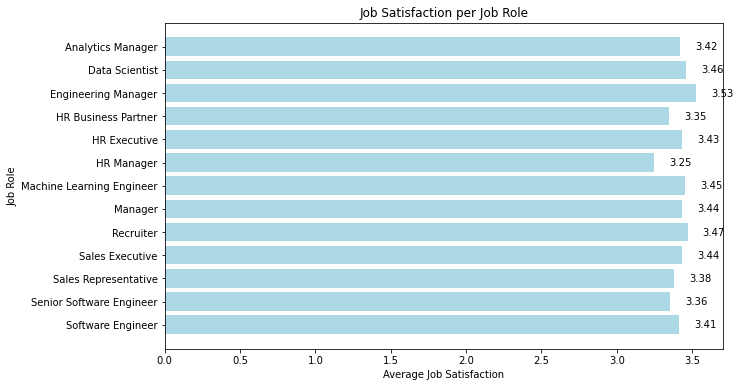

,JobRole,JobSatisfaction
0,Analytics Manager,3.418269
1,Data Scientist,3.457353
2,Engineering Manager,3.526490
3,HR Business Partner,3.347826
4,HR Executive,3.434783
5,HR Manager,3.250000
6,Machine Learning Engineer,3.453405
7,Manager,3.435714
8,Recruiter,3.469799
9,Sales Executive,3.435897


In [26]:
# Q26: Job Satisfaction Per Job Role
unique_employees = df[['EmployeeID', 'JobSatisfaction', 'JobRole']]

# حساب متوسط الرضا الوظيفي حسب الدور الوظيفي
job_role_job_satisfaction = unique_employees.groupby('JobRole').agg({'JobSatisfaction': 'mean'}).reset_index()

# رسم البيانات
plt.figure(figsize=(10, 6))
bars = plt.barh(job_role_job_satisfaction['JobRole'], job_role_job_satisfaction['JobSatisfaction'], color='lightblue')
plt.xlabel('Average Job Satisfaction')
plt.ylabel('Job Role')
plt.title('Job Satisfaction per Job Role')
plt.gca().invert_yaxis()  # To display the highest on top

# إضافة البيانات على الرسم البياني
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.1, bar.get_y() + bar.get_height() / 2,
             f'{width:.2f}', va='center', ha='left', color='black')

plt.show()

job_role_job_satisfaction


C:\Users\hp\AppData\Local\Temp\ipykernel_23128\1469401951.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  unique_employees['SalaryCategory'] = pd.cut(unique_employees['Salary'], bins=[0, 50000, 150000, float('inf')],


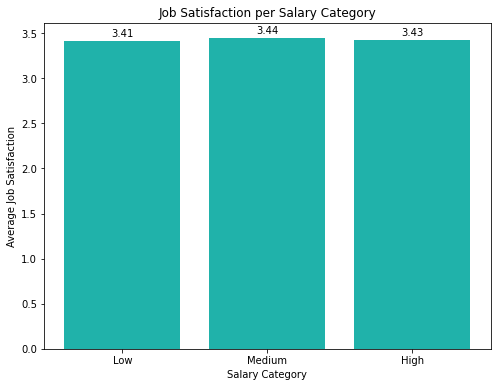

,SalaryCategory,JobSatisfaction
0,Low,3.412875
1,Medium,3.444303
2,High,3.426273


In [27]:
# Q27: Job Satisfaction per Salary Category
unique_employees = df[['EmployeeID', 'JobSatisfaction', 'Salary']]

# تصنيف الراتب إلى ثلاث فئات: Low, Medium, High
unique_employees['SalaryCategory'] = pd.cut(unique_employees['Salary'], bins=[0, 50000, 150000, float('inf')],
                                            labels=['Low', 'Medium', 'High'])

# حساب متوسط الرضا الوظيفي حسب فئة الراتب
salary_job_satisfaction = unique_employees.groupby('SalaryCategory').agg({'JobSatisfaction': 'mean'}).reset_index()

# رسم البيانات
plt.figure(figsize=(8, 6))
bars = plt.bar(salary_job_satisfaction['SalaryCategory'], salary_job_satisfaction['JobSatisfaction'], color='lightseagreen')
plt.xlabel('Salary Category')
plt.ylabel('Average Job Satisfaction')
plt.title('Job Satisfaction per Salary Category')

# إضافة البيانات على الرسم البياني
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.05, f'{height:.2f}', ha='center', color='black')

plt.show()

salary_job_satisfaction


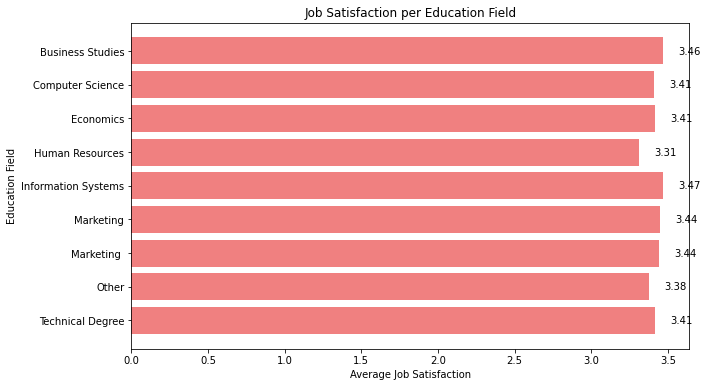

,EducationField,JobSatisfaction
0,Business Studies,3.463736
1,Computer Science,3.410938
2,Economics,3.414798
3,Human Resources,3.308271
4,Information Systems,3.465327
5,Marketing,3.444730
6,Marketing,3.439791
7,Other,3.376694
8,Technical Degree,3.412281


In [28]:
# Q28: Education Field Correlation with Job Satisfaction
education_field_job_satisfaction = df.groupby('EducationField')['JobSatisfaction'].mean().reset_index()

# رسم البيانات
plt.figure(figsize=(10, 6))
bars = plt.barh(education_field_job_satisfaction['EducationField'], education_field_job_satisfaction['JobSatisfaction'], color='lightcoral')
plt.xlabel('Average Job Satisfaction')
plt.ylabel('Education Field')
plt.title('Job Satisfaction per Education Field')
plt.gca().invert_yaxis()  # To display the highest on top

# إضافة البيانات على الرسم البياني
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.1, bar.get_y() + bar.get_height() / 2,
             f'{width:.2f}', va='center', ha='left', color='black')

plt.show()

education_field_job_satisfaction


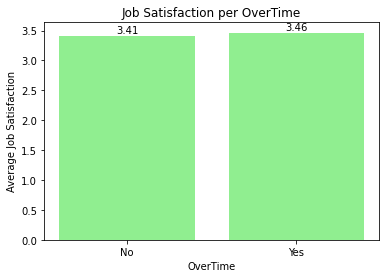

,OverTime,JobSatisfaction
0,No,3.413685
1,Yes,3.464461


In [29]:
# Q29: Job Satisfaction per OverTime
unique_employees = df[['EmployeeID', 'JobSatisfaction', 'OverTime']]

# حساب متوسط الرضا الوظيفي حسب العمل الإضافي
overtime_job_satisfaction = unique_employees.groupby('OverTime').agg({'JobSatisfaction': 'mean'}).reset_index()

# رسم البيانات
plt.figure(figsize=(6, 4))
bars = plt.bar(overtime_job_satisfaction['OverTime'], overtime_job_satisfaction['JobSatisfaction'], color='lightgreen')
plt.xlabel('OverTime')
plt.ylabel('Average Job Satisfaction')
plt.title('Job Satisfaction per OverTime')

# إضافة البيانات على الرسم البياني
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.05, f'{height:.2f}', ha='center', color='black')

plt.show()

overtime_job_satisfaction


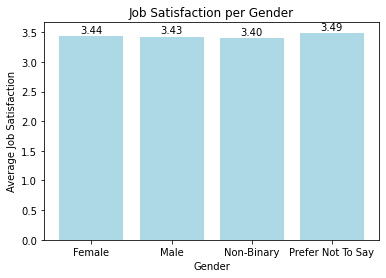

,Gender,JobSatisfaction
0,Female,3.437075
1,Male,3.427898
2,Non-Binary,3.404075
3,Prefer Not To Say,3.491803


In [30]:
# Q30: Job Satisfaction per Gender
unique_employees = df[['EmployeeID', 'JobSatisfaction', 'Gender']]

# حساب متوسط الرضا الوظيفي حسب الجنس
gender_job_satisfaction = unique_employees.groupby('Gender').agg({'JobSatisfaction': 'mean'}).reset_index()

# رسم البيانات
plt.figure(figsize=(6, 4))
bars = plt.bar(gender_job_satisfaction['Gender'], gender_job_satisfaction['JobSatisfaction'], color='lightblue')
plt.xlabel('Gender')
plt.ylabel('Average Job Satisfaction')
plt.title('Job Satisfaction per Gender')

# إضافة البيانات على الرسم البياني
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.05, f'{height:.2f}', ha='center', color='black')

plt.show()

gender_job_satisfaction


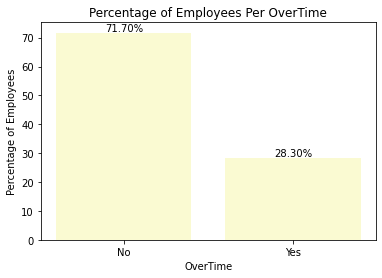

,OverTime,EmployeeID,% of Overtime
0,No,1054,71.70068
1,Yes,416,28.29932


In [31]:
# Q31: Percentage of Employees Per OverTime
unique_employees = df[['EmployeeID', 'OverTime']].drop_duplicates()

# حساب عدد الموظفين الذين يعملون ساعات إضافية
overtime_percentage = unique_employees.groupby('OverTime').agg({
    'EmployeeID': 'count'
}).reset_index()

# حساب نسبة الموظفين الذين يعملون ساعات إضافية
overtime_percentage['% of Overtime'] = 100.0 * overtime_percentage['EmployeeID'] / unique_employees['EmployeeID'].nunique()

# رسم البيانات
plt.figure(figsize=(6, 4))
bars = plt.bar(overtime_percentage['OverTime'], overtime_percentage['% of Overtime'], color='lightgoldenrodyellow')
plt.xlabel('OverTime')
plt.ylabel('Percentage of Employees')
plt.title('Percentage of Employees Per OverTime')

# إضافة البيانات على الرسم البياني
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.5, f'{height:.2f}%', ha='center', color='black')

plt.show()

overtime_percentage


In [32]:
# إزالة التكرارات بناءً على "EmployeeID" (بحيث يتم أخذ الموظف الواحد فقط)
unique_employees = df[['EmployeeID', 'OverTime']].drop_duplicates()

# حساب عدد الموظفين الذين عملوا ساعات إضافية
overtime_employees_count = unique_employees[unique_employees['OverTime'] == 1].shape[0]

# إجمالي عدد الموظفين (محددة مسبقاً كـ 1460)
total_employees = 1460

# حساب النسبة المئوية
overtime_percentage = (overtime_employees_count / total_employees) * 100

# طباعة النتائج
print(f"عدد الموظفين الذين عملوا ساعات إضافية: {overtime_employees_count}")
print(f"نسبة الموظفين الذين عملوا ساعات إضافية: {overtime_percentage:.2f}%")


عدد الموظفين الذين عملوا ساعات إضافية: 0
نسبة الموظفين الذين عملوا ساعات إضافية: 0.00%


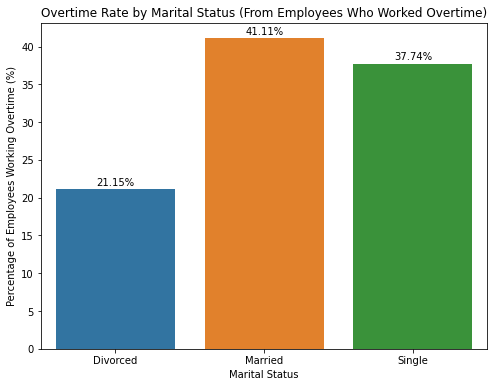

MaritalStatus
Divorced    21.153846
Married     41.105769
Single      37.740385
dtype: float64


In [33]:
# Q32: % Of Employees Over Time Per Marital Status

# تحويل "Yes" إلى 1 و "No" إلى 0 في عمود 'OverTime'
df['OverTime'] = df['OverTime'].replace({'Yes': 1, 'No': 0})

# تأكد من أن العمود يحتوي فقط على القيم الرقمية
df['OverTime'] = pd.to_numeric(df['OverTime'], errors='coerce')

# تحديد الموظفين الذين عملوا ساعات إضافية فقط
overtime_employees = df[df['OverTime'] == 1]

# إزالة التكرار في بيانات الموظفين (حسب EmployeeID)
overtime_employees = overtime_employees.drop_duplicates(subset=['EmployeeID'])

# حساب عدد الموظفين الذين عملوا ساعات إضافية حسب الحالة الاجتماعية
overtime_marital = overtime_employees.groupby('MaritalStatus').size()

# إجمالي عدد الموظفين الذين عملوا ساعات إضافية (416 موظفًا بعد إزالة التكرار)
total_overtime_employees = 416

# حساب النسبة المئوية للموظفين الذين يعملون ساعات إضافية حسب الحالة الاجتماعية
overtime_marital_percentage = (overtime_marital / total_overtime_employees) * 100

# Visualization - Bar chart
plt.figure(figsize=(8, 6))
sns.barplot(x=overtime_marital_percentage.index, y=overtime_marital_percentage.values)
plt.title('Overtime Rate by Marital Status (From Employees Who Worked Overtime)')
plt.ylabel('Percentage of Employees Working Overtime (%)')
plt.xlabel('Marital Status')

# إضافة البيانات على الرسم البياني
for i, value in enumerate(overtime_marital_percentage.values):
    plt.text(i, value + 0.5, f'{value:.2f}%', ha='center', color='black')

plt.show()

# عرض النتيجة
print(overtime_marital_percentage)




In [34]:
# Q33: Avg Monthly Salaries
unique_employees = df[['EmployeeID', 'Salary']].drop_duplicates()

# حساب متوسط الراتب الشهري
unique_employees['MonthlySalary'] = unique_employees['Salary'] / 12
avg_monthly_salary = unique_employees['MonthlySalary'].mean()

# حساب عدد الموظفين
total_employees = unique_employees['EmployeeID'].nunique()

# طباعة النتيجة
print(f"Avg Monthly Salary: {avg_monthly_salary:.2f}")
print(f"Total Employees: {total_employees}")


Avg Monthly Salary: 9413.04
Total Employees: 1470


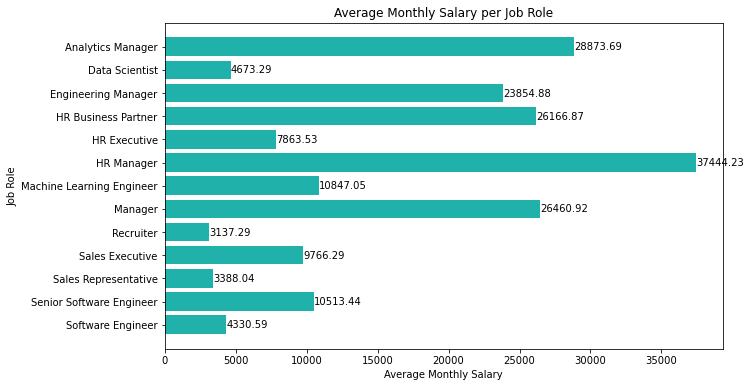

,JobRole,MonthlySalary
0,Analytics Manager,28873.685897
1,Data Scientist,4673.291188
2,Engineering Manager,23854.875556
3,HR Business Partner,26166.869048
4,HR Executive,7863.526786
5,HR Manager,37444.229167
6,Machine Learning Engineer,10847.051370
7,Manager,26460.921171
8,Recruiter,3137.291667
9,Sales Executive,9766.294852


In [35]:
# Q34: Avg Monthly Salaries Per Job Role
unique_employees = df[['EmployeeID', 'Salary', 'JobRole']].drop_duplicates()

# حساب الراتب الشهري لكل موظف
unique_employees['MonthlySalary'] = unique_employees['Salary'] / 12

# حساب متوسط الراتب الشهري حسب الدور الوظيفي
avg_salary_per_job_role = unique_employees.groupby('JobRole')['MonthlySalary'].mean().reset_index()

# رسم البيانات
plt.figure(figsize=(10, 6))
bars = plt.barh(avg_salary_per_job_role['JobRole'], avg_salary_per_job_role['MonthlySalary'], color='lightseagreen')
plt.xlabel('Average Monthly Salary')
plt.ylabel('Job Role')
plt.title('Average Monthly Salary per Job Role')
plt.gca().invert_yaxis()  # To display the highest on top

# إضافة البيانات على الرسم البياني
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.1, bar.get_y() + bar.get_height() / 2,
             f'{width:.2f}', va='center', ha='left', color='black')

plt.show()

avg_salary_per_job_role



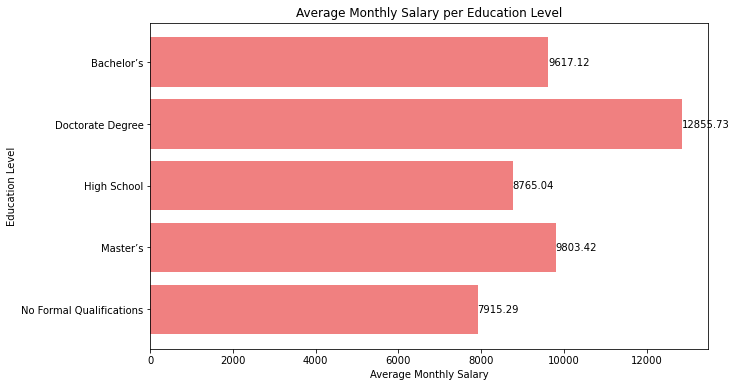

,EducationLevel,MonthlySalary
0,Bachelor’s,9617.119172
1,Doctorate Degree,12855.732639
2,High School,8765.044622
3,Master’s,9803.421482
4,No Formal Qualifications,7915.290196


In [36]:
# Q35: Avg Monthly Salaries Per Education Level
unique_employees = df[['EmployeeID', 'Salary', 'EducationLevel']].drop_duplicates()

# حساب الراتب الشهري لكل موظف
unique_employees['MonthlySalary'] = unique_employees['Salary'] / 12

# حساب متوسط الراتب الشهري حسب المستوى التعليمي
avg_salary_per_education_level = unique_employees.groupby('EducationLevel')['MonthlySalary'].mean().reset_index()

# رسم البيانات
plt.figure(figsize=(10, 6))
bars = plt.barh(avg_salary_per_education_level['EducationLevel'], avg_salary_per_education_level['MonthlySalary'], color='lightcoral')
plt.xlabel('Average Monthly Salary')
plt.ylabel('Education Level')
plt.title('Average Monthly Salary per Education Level')
plt.gca().invert_yaxis()  # To display the highest on top

# إضافة البيانات على الرسم البياني
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.1, bar.get_y() + bar.get_height() / 2,
             f'{width:.2f}', va='center', ha='left', color='black')

plt.show()

avg_salary_per_education_level
